In [1]:
# Labial 

import sys
sys.path.append('/volume_4/research/seongbong/flywire/geosmin_project_version_update/code')
from analysis_of_simulation_result import * 

import numpy as np 
import pandas as pd 
import os 
import pickle
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from cell_groups import *
from color_utils import * 
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

In [2]:
from scipy.stats import hmean

DATA_DIR = Path.cwd().resolve().parents[0]/'data'

def load_screening_result(filename, sheet_name):
    df = pd.read_excel(
        DATA_DIR / filename,
        sheet_name=sheet_name,
        header=1,
        index_col=0,
    )

    if "type" in df.index:
        df = df.drop(index="type")

    df.index.name = "type"
    return df

def calculate_network_characteristics(activation,silence,mode='sweet'):
    
    df_per_concent = {}
    for concent in silence.columns:
        if mode == 'sweet':
            slnc = silence[concent]
            act = activation[0]
            N = (slnc.loc['control'] - slnc)/slnc.loc['control']
            S = act - act.loc['control']
        else:
            slnc = silence[concent]
            act = activation[concent]
            N = (slnc - slnc.loc['control'])/slnc.loc['control']
            S = (act.loc['control'] - act)/act.loc['control']
        N = N.clip(lower=0)
        S = S.clip(lower=0)
        N, S = N.align(S)
        HM = hmean(np.vstack([N,S]))
        df = pd.DataFrame({
            'Necessity': N,
            'Sufficiency': S,
            'HM': HM
        }, index=N.index)    
        df['rank'] = df['HM'].rank(ascending=False, method='min').astype(int)
        df_per_concent[concent] = df 
    
    return df_per_concent 



### Sweet ###
# Tarsal
tarsal_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "tarsal",
)
tarsal_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "tarsal",
)


# Labellar
labial_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "labellar",
)
labial_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "labellar",
)
labial_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "labellar",
)



### Sweet ###
# Tarsal
tarsal_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "labellar",
)
labial_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "labellar",
)
labial_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "labellar",
)




tarsal_sweet_df = calculate_network_characteristics(tarsal_activation_per,tarsal_screening_per,mode='sweet')
labial_sweet_df = calculate_network_characteristics(labial_activation_per,labial_screening_per,mode='sweet')
tarsal_geosmin_df = calculate_network_characteristics(tarsal_geosmin_activation_per,tarsal_geosmin_screening_per,mode='geosmin')
labial_geosmin_df = calculate_network_characteristics(labial_geosmin_activation_per,labial_geosmin_screening_per,mode='geosmin')


In [3]:
# Rank data to Set color of nodes 
def make_rank_color_info(rank_df, top_n=20, base_color="#FF0066", default_color="#777777"):
    num_top_ranked = (rank_df <= top_n).sum(axis=1)

    return {
        tid: (
            get_graded_color(base_color, int(num))
            if num > 2
            else default_color
        )
        for tid, num in num_top_ranked.items()
    }


Rank_DATA_DIR = Path.cwd().resolve().parents[0]/'figure5Q,R/data'
tarsal_sweet_rank_df = pd.read_parquet(Rank_DATA_DIR/'tarsal_sweet_rank.parquet')
labial_sweet_rank_df = pd.read_parquet(Rank_DATA_DIR/'labial_sweet_rank.parquet')
tarsal_geosmin_rank_df = pd.read_parquet(Rank_DATA_DIR/'tarsal_geosmin_rank.parquet')
labial_geosmin_rank_df = pd.read_parquet(Rank_DATA_DIR/'labial_geosmin_rank.parquet')


color_info_tarsal_sweet = make_rank_color_info(
    tarsal_sweet_rank_df,
    top_n=20,
    base_color="#0066FF",
)

color_info_labial_sweet = make_rank_color_info(
    labial_sweet_rank_df,
    top_n=20,
    base_color="#00AA66",
)

color_info_tarsal_geosmin = make_rank_color_info(
    tarsal_geosmin_rank_df,
    top_n=20,
    base_color="#FF0066",
)


color_info_labial_geosmin = make_rank_color_info(
    labial_geosmin_rank_df,
    top_n=20,
    base_color="#FF0066",
)

# Tarsal Sweet

In [4]:
df_mean = (
    pd.concat(tarsal_sweet_df.values())
      .groupby(level=0)
      .mean()
)

x = df_mean['Necessity']
x = x.drop(['control'])
y = df_mean['Sufficiency']
y = y.drop(['control'])

In [6]:
df_mean['Necessity']

type
1485       0.673633
17         0.009313
1785       0.010993
1870       0.004732
1882       0.001420
1982       0.015346
2084       0.009258
2125       0.000457
2158       0.027323
23         0.019903
2553       0.011599
2673       0.008284
2764       0.008665
2951       0.001259
3          0.020454
302        0.019780
3032       0.122070
3113       0.018039
3154       0.039176
3870       0.004951
4134       0.009763
4216       0.007467
4217       0.092263
4453       0.005878
452        0.033350
5304       0.356427
5342       0.421619
535        0.266184
5417       0.010997
5467       0.140726
5523       0.069791
5766       0.006141
5881       0.006355
6033       0.002642
6103       0.283256
6114       0.031396
6286       0.721246
6294       0.003208
6395       0.002749
7014       0.426973
7272       0.244132
7328       0.007453
7625       0.715690
8445       0.172214
8504       0.020521
8586       0.240975
8689       0.027492
8781       0.026901
9036       0.228744
955        0.01

/tmp/ipykernel_77601/2178429657.py:58: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

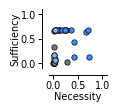

In [39]:
ps = 15
fig, ax = plt.subplots(1, 1, figsize=(1.2, 1), constrained_layout=True)

# 먼저 회색 노드
for label in x.index:
    if color_info_tarsal_sweet[label] == '#777777':
        ax.scatter(
            x.loc[label], y.loc[label],
            s=ps,
            color=color_info_tarsal_sweet[label],
            edgecolors='black',
            linewidths=0.5,
        )

# 그 다음 나머지 노드
for label in x.index:
    if color_info_tarsal_sweet[label] != '#777777':
        ax.scatter(
            x.loc[label], y.loc[label],
            s=ps,
            color=color_info_tarsal_sweet[label],
            edgecolors='black',
            linewidths=0.5,
        )

ax.set_ylim([-.1, 1.1])
ax.set_xlim([-.1, 1.1])
ax.set_yticks(np.arange(0, 1.2, .5))
ax.set_xticks(np.arange(0, 1.2, .5))
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Sufficiency')
ax.set_xlabel('Necessity')
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)
ax.spines['left'].set_linewidth(0.7)
ax.spines['bottom'].set_linewidth(0.7)

# tick 두께
ax.tick_params(
    axis='both',
    width=0.7,      # tick line 두께
    length=3,       # (선택) tick 길이
    pad=1
)

ax.set_aspect(
    'equal',
    adjustable='box'
)

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32      # 45도 xtick 기준으로 통일
fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)
plt.savefig('figures/Tarsal.svg')

# Labellar Sweet 

In [20]:
df_mean = (
    pd.concat(labial_sweet_df.values())
      .groupby(level=0)
      .mean()
)

x = df_mean['Necessity']
x = x.drop(['control'])
y = df_mean['Sufficiency']
y = y.drop(['control'])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

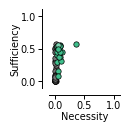

In [21]:
ps = 15
fig, ax = plt.subplots(1, 1, figsize=(1.2, 1), constrained_layout=True)

# 먼저 회색 노드
for label in x.index:
    if color_info_labial_sweet[label] == '#777777':
        ax.scatter(
            x.loc[label], y.loc[label],
            s=ps,
            color=color_info_labial_sweet[label],
            edgecolors='black',
            linewidths=0.5,
        )

# 그 다음 나머지 노드
for label in x.index:
    if color_info_labial_sweet[label] != '#777777':
        ax.scatter(
            x.loc[label], y.loc[label],
            s=ps,
            color=color_info_labial_sweet[label],
            edgecolors='black',
            linewidths=0.5,
        )

ax.set_ylim([-.1, 1.1])
ax.set_xlim([-.1, 1.1])
ax.set_yticks(np.arange(0, 1.2, .5))
ax.set_xticks(np.arange(0, 1.2, .5))
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Sufficiency')
ax.set_xlabel('Necessity')
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)
ax.spines['left'].set_linewidth(0.7)
ax.spines['bottom'].set_linewidth(0.7)
ax.tick_params(
    axis='both',
    width=0.7,      # tick line 두께
    length=3,       # (선택) tick 길이
    pad=1
)

# Tarsal Geosmin

In [22]:
df_mean = (
    pd.concat(tarsal_geosmin_df.values())
      .groupby(level=0)
      .mean()
)

x = df_mean['Necessity']
x = x.drop(['control'])
y = df_mean['Sufficiency']
y = y.drop(['control'])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

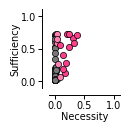

In [25]:
ps = 20
fig, ax = plt.subplots(1, 1, figsize=(1.2, 1), constrained_layout=True)

# 먼저 회색 노드
for label in x.index:
    if color_info_tarsal_geosmin[label] == '#777777':
        ax.scatter(
            x.loc[label], y.loc[label],
            s=ps,
            color=color_info_tarsal_geosmin[label],
            edgecolors='black',
            linewidths=0.5,
        )

# 그 다음 나머지 노드
for label in x.index:
    if color_info_tarsal_geosmin[label] != '#777777':
        ax.scatter(
            x.loc[label], y.loc[label],
            s=ps,
            color=color_info_tarsal_geosmin[label],
            edgecolors='black',
            linewidths=0.5,
        )

ax.set_ylim([-.1, 1.1])
ax.set_xlim([-.1, 1.1])
ax.set_yticks(np.arange(0, 1.2, .5))
ax.set_xticks(np.arange(0, 1.2, .5))
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Sufficiency')
ax.set_xlabel('Necessity')
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)
ax.spines['left'].set_linewidth(0.7)
ax.spines['bottom'].set_linewidth(0.7)

# tick 두께
ax.tick_params(
    axis='both',
    width=0.7,      # tick line 두께
    length=3,       # (선택) tick 길이
    pad=1
)

# Labellar Geosmin

In [26]:
df_mean = (
    pd.concat(labial_geosmin_df.values())
      .groupby(level=0)
      .mean()
)

x = df_mean['Necessity']
x = x.drop(['control'])
y = df_mean['Sufficiency']
y = y.drop(['control'])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

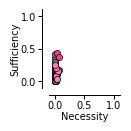

In [27]:
ps = 20
fig, ax = plt.subplots(1, 1, figsize=(1.2, 1), constrained_layout=True)

# 먼저 회색 노드
for label in x.index:
    if color_info_labial_geosmin[label] == '#777777':
        ax.scatter(
            x.loc[label], y.loc[label],
            s=ps,
            color=color_info_labial_geosmin[label],
            edgecolors='black',
            linewidths=0.5,
        )

# 그 다음 나머지 노드
for label in x.index:
    if color_info_labial_geosmin[label] != '#777777':
        ax.scatter(
            x.loc[label], y.loc[label],
            s=ps,
            color=color_info_labial_geosmin[label],
            edgecolors='black',
            linewidths=0.5,
        )

ax.set_ylim([-.1, 1.1])
ax.set_xlim([-.1, 1.1])
ax.set_yticks(np.arange(0, 1.2, .5))
ax.set_xticks(np.arange(0, 1.2, .5))
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Sufficiency')
ax.set_xlabel('Necessity')
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)
ax.spines['left'].set_linewidth(0.7)
ax.spines['bottom'].set_linewidth(0.7)

# tick 두께
ax.tick_params(
    axis='both',
    width=0.7,      # tick line 두께
    length=3,       # (선택) tick 길이
    pad=1
)